In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

In [2]:
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [3]:
design_matrix = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)

In [4]:
design_matrix.shape

(680, 65)

In [5]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance", 
]

In [6]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    design_matrix['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix['sofa_score_increase_day3'] > 1, 1, 0
    )
)

design_matrix_test['future_deterioration'] = np.where(
    design_matrix_test['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix_test['sofa_score_increase_day3'] > 1, 1, 0
    )
)

In [7]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
constant_imputer = SimpleImputer(strategy="constant", fill_value=0.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[categorical_clinical_columns] = constant_imputer.fit_transform(training_data[categorical_clinical_columns])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])


testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[categorical_clinical_columns] = constant_imputer.transform(testing_data[categorical_clinical_columns])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])

In [8]:
df_estimator = DigitalFamilyBinary(
    n_neighbors=20
)
df_estimator.fit(training_data, features=clinical_columns)

# 30-day Mortality

In [9]:
testing_data['Mortality 30 Day Prob'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="survival_30_day"
)

In [10]:
combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [11]:

bootstrap_counts = []


for bootstrap_iteration in df_estimator.bootstrap_columns:


    mort_range = combined_results[bootstrap_iteration].unique()
    mort_range.sort()
    actual_mort = []
    #mort_range = mort_range[:-1]
    counts_per_bin = []
    for val in mort_range:

        counts = combined_results[combined_results[bootstrap_iteration] == val]['survival_30_day'].value_counts()
        actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
        counts_per_bin.append(counts.sum())

    estimated_mort = pd.DataFrame(
        {
            "Actual Mortality (30-Day)": actual_mort,
            "Estimated Mortality (30-Day)": mort_range,
            "Counts": counts_per_bin
        }
    )

    bootstrap_counts.append(estimated_mort)

In [12]:
bootstrap_counts = pd.concat(bootstrap_counts)

In [13]:
bootstrap_counts.head(20)

,Actual Mortality (30-Day),Estimated Mortality (30-Day),Counts
0,0.064057,0.00,281
1,0.102151,0.05,186
2,0.201923,0.10,104
3,0.127273,0.15,55
4,0.222222,0.20,27
5,0.363636,0.25,11
6,0.444444,0.30,9
7,0.750000,0.35,4
8,0.000000,0.40,1
9,1.000000,0.45,2


In [14]:
bootstrap_counts.to_csv(
    "mortality_df.tsv",
    sep="\t",
    index=False
)

In [15]:
from scipy import stats
def r2(x, y):
    return stats.pearsonr(x, y)[0] ** 2

In [16]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(bootstrap_counts[['Estimated Mortality (30-Day)']], bootstrap_counts[['Actual Mortality (30-Day)']])

LinearRegression()

In [17]:
from scipy.stats import linregress


linregress_results = linregress(bootstrap_counts[['Estimated Mortality (30-Day)']].values.ravel(), bootstrap_counts[['Actual Mortality (30-Day)']].values.ravel())
linregress_results


LinregressResult(slope=np.float64(1.9575144980779324), intercept=np.float64(-0.046821070215356086), rvalue=np.float64(0.8728665225511253), pvalue=np.float64(5.064255642113031e-307), stderr=np.float64(0.034992188022598056), intercept_stderr=np.float64(0.009228832097832797))

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts[['Estimated Mortality (30-Day)']].values.ravel()

In [19]:
from scipy.stats import pearsonr

corr, pval = pearsonr(
    bootstrap_counts[['Estimated Mortality (30-Day)']].values.ravel(), bootstrap_counts[['Actual Mortality (30-Day)']].values.ravel()
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


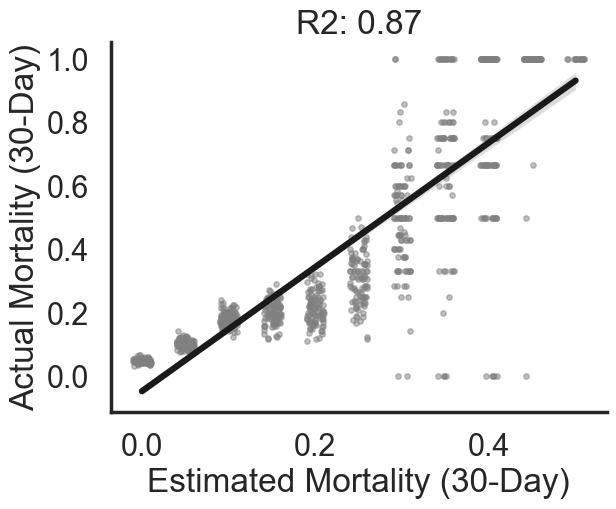

In [20]:
import matplotlib.pyplot as plt

sns.set_theme(context="poster", style="white", font_scale=1)

fig, ax = plt.subplots()

sns.regplot(
    data=bootstrap_counts,
    x="Estimated Mortality (30-Day)",
    y="Actual Mortality (30-Day)",
    ax=ax,
    scatter_kws={"color": "gray", "alpha": 0.5, "s": 15},
    line_kws={"color": "k", "alpha": 1},
    fit_reg=True,
    ci=95,
    x_jitter=0.01
)

ax.set_title(
    f"R2: {corr:.2f}"
)

sns.despine()


In [21]:
estimated_mort['Predicted Fit'] = linreg.predict(estimated_mort[['Estimated Mortality (30-Day)']])

In [22]:
fig.savefig("mortality.pdf", dpi=300, bbox_inches="tight")

In [23]:
combined_results.to_csv(
    "design_matrix_test_mortality_risk.tsv",
    sep="\t"
)

# Deterioration

In [24]:
# training_data = design_matrix[
#     #(X['sofa_score_increase_day1'] < 2) &
#     (~design_matrix['sofa_score_increase_day2'].isna()) &
#     (~design_matrix['sofa_score_increase_day3'].isna())
# ].copy()

In [25]:
# testing_data = design_matrix_test[
#      #(X_test['sofa_score_increase_day1'] < 2) &
#     (~design_matrix_test['sofa_score_increase_day2'].isna()) &
#     (~design_matrix_test['sofa_score_increase_day3'].isna())
# ].copy()

In [26]:
# from sklearn.preprocessing import StandardScaler, LabelBinarizer
# from sklearn.impute import SimpleImputer
#
# clinical_scaler = StandardScaler()
#
# clinical_imputer = SimpleImputer()
# constant_imputer = SimpleImputer(strategy="constant", fill_value=0.0)
#
# training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
# training_data[categorical_clinical_columns] = constant_imputer.fit_transform(training_data[categorical_clinical_columns])
#
# training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
#
#
# testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
# testing_data[categorical_clinical_columns] = constant_imputer.transform(testing_data[categorical_clinical_columns])
#
# testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])

In [27]:
# df_estimator = DigitalFamilyBinary()
#
# df_estimator.fit(training_data, features=clinical_columns)

In [28]:
testing_data['Future Deterioration Mean'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="future_deterioration"
)

In [29]:
combined_results = pd.concat([testing_data.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

In [30]:

bootstrap_counts = []


for bootstrap_iteration in df_estimator.bootstrap_columns:


    mort_range = combined_results[bootstrap_iteration].unique()
    mort_range.sort()
    actual_mort = []
    #mort_range = mort_range[:-1]
    counts_per_bin = []
    for val in mort_range:

        counts = combined_results[combined_results[bootstrap_iteration] == val]['future_deterioration'].value_counts()
        actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
        counts_per_bin.append(counts.sum())

    estimated_mort = pd.DataFrame(
        {
            "Actual Deterioration": actual_mort,
            "Estimated Deterioration": mort_range,
            "Counts": counts_per_bin
        }
    )

    bootstrap_counts.append(estimated_mort)

In [31]:
bootstrap_counts = pd.concat(bootstrap_counts)

In [32]:
bootstrap_counts.head(20)

,Actual Deterioration,Estimated Deterioration,Counts
0,0.500000,0.10,4
1,0.076923,0.15,13
2,0.392857,0.20,28
3,0.181818,0.25,22
4,0.422222,0.30,45
5,0.385965,0.35,57
6,0.554217,0.40,83
7,0.466667,0.45,90
8,0.532609,0.50,92
9,0.636364,0.55,88


In [33]:
bootstrap_counts.to_csv(
    "deterioration_df.tsv",
    sep="\t",
    index=False
)

In [34]:
from scipy import stats
def r2(x, y):
    return stats.pearsonr(x, y)[0] ** 2

In [35]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(bootstrap_counts[['Estimated Deterioration']], bootstrap_counts[['Actual Deterioration']])

LinearRegression()

In [36]:
from scipy.stats import linregress


linregress_results = linregress(bootstrap_counts[['Estimated Deterioration']].values.ravel(), bootstrap_counts[['Actual Deterioration']].values.ravel())
linregress_results


LinregressResult(slope=np.float64(0.5881057961620316), intercept=np.float64(0.21084080333856164), rvalue=np.float64(0.6442500303040163), pvalue=np.float64(1.349358023702242e-208), stderr=np.float64(0.016585383512774485), intercept_stderr=np.float64(0.009177778786211607))

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts[['Estimated Deterioration']].values.ravel()

In [38]:
from scipy.stats import pearsonr

corr, pval = pearsonr(
    bootstrap_counts[['Estimated Deterioration']].values.ravel(), bootstrap_counts[['Actual Deterioration']].values.ravel()
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


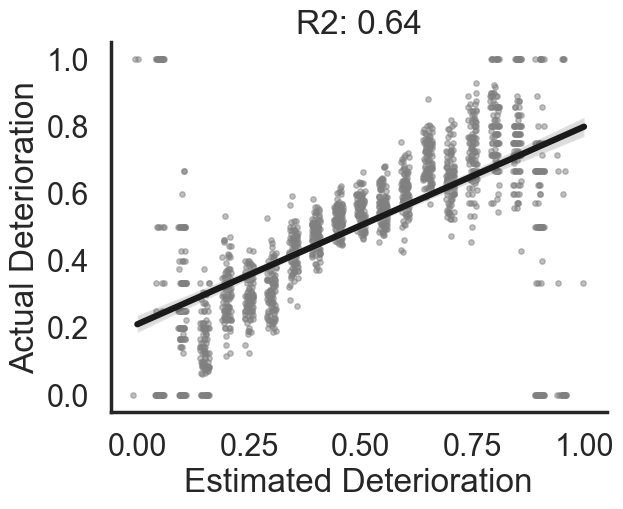

In [39]:
import matplotlib.pyplot as plt

sns.set_theme(context="poster", style="white", font_scale=1)

fig, ax = plt.subplots()

sns.regplot(
    data=bootstrap_counts,
    x="Estimated Deterioration",
    y="Actual Deterioration",
    ax=ax,
    scatter_kws={"color": "gray", "alpha": 0.5, "s": 15},
    line_kws={"color": "k", "alpha": 1},
    fit_reg=True,
    ci=95,
    x_jitter=0.01
)

ax.set_title(
    f"R2: {corr:.2f}"
)

sns.despine()

In [40]:
fig.savefig("deterioration.pdf", dpi=300, bbox_inches="tight")

In [41]:
combined_results.to_csv(
    "design_matrix_test_deterioration.tsv",
    sep="\t"
)

# Sepsis

In [42]:
testing_data['Sepsis Prob'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock"
)

In [43]:
combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [44]:

bootstrap_counts = []

for bootstrap_iteration in df_estimator.bootstrap_columns:


    mort_range = combined_results[bootstrap_iteration].unique()
    mort_range.sort()
    actual_mort = []
    #mort_range = mort_range[:-1]
    counts_per_bin = []
    for val in mort_range:

        counts = combined_results[combined_results[bootstrap_iteration] == val]['sepsis_or_septic_shock'].value_counts()
        actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
        counts_per_bin.append(counts.sum())

    estimated_mort = pd.DataFrame(
        {
            "Actual Sepsis": actual_mort,
            "Estimated Sepsis": mort_range,
            "Counts": counts_per_bin
        }
    )

    bootstrap_counts.append(estimated_mort)

In [45]:
bootstrap_counts = pd.concat(bootstrap_counts)

In [46]:
bootstrap_counts.head(20)

,Actual Sepsis,Estimated Sepsis,Counts
0,0.000000,0.20,1
1,0.500000,0.25,2
2,0.153846,0.30,13
3,0.285714,0.35,14
4,0.400000,0.40,30
5,0.382353,0.45,34
6,0.478261,0.50,46
7,0.672131,0.55,61
8,0.643836,0.60,73
9,0.698630,0.65,73


In [47]:
bootstrap_counts.to_csv(
    "sepsis_df.tsv",
    sep="\t",
    index=False
)

In [48]:
from scipy import stats
def r2(x, y):
    return stats.pearsonr(x, y)[0] ** 2

In [49]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(bootstrap_counts[['Estimated Sepsis']], bootstrap_counts[['Actual Sepsis']])

LinearRegression()

In [50]:
from scipy.stats import linregress


linregress_results = linregress(bootstrap_counts[['Estimated Sepsis']].values.ravel(), bootstrap_counts[['Actual Sepsis']].values.ravel())
linregress_results


LinregressResult(slope=np.float64(1.141233783131726), intercept=np.float64(-0.099143656468339), rvalue=np.float64(0.9523716746117877), pvalue=np.float64(0.0), stderr=np.float64(0.0089284207585964), intercept_stderr=np.float64(0.0058209550754395305))

In [51]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts[['Estimated Sepsis']].values.ravel()

In [52]:
from scipy.stats import pearsonr

corr, pval = pearsonr(
    bootstrap_counts[['Estimated Sepsis']].values.ravel(), bootstrap_counts[['Actual Sepsis']].values.ravel()
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


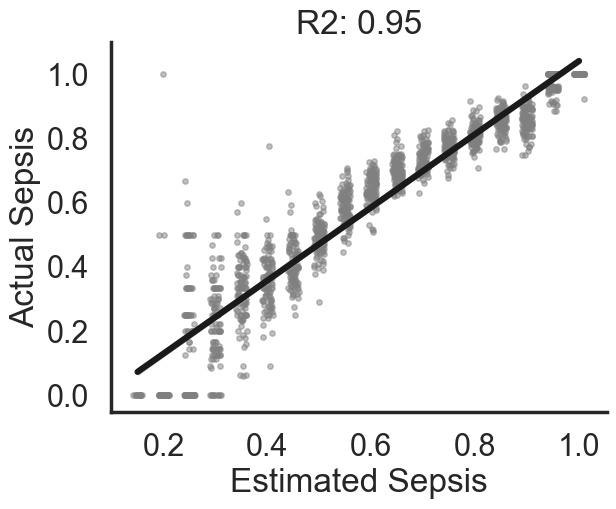

In [53]:
import matplotlib.pyplot as plt

sns.set_theme(context="poster", style="white", font_scale=1)

fig, ax = plt.subplots()

sns.regplot(
    data=bootstrap_counts,
    x="Estimated Sepsis",
    y="Actual Sepsis",
    ax=ax,
    scatter_kws={"color": "gray", "alpha": 0.5, "s": 15},
    line_kws={"color": "k", "alpha": 1},
    fit_reg=True,
    ci=95,
    x_jitter=0.01
)

ax.set_title(
    f"R2: {corr:.2f}"
)

sns.despine()

In [54]:
combined_results.to_csv(
    "design_matrix_test_sepsis_risk.tsv",
    sep="\t",
    index=False
)

In [55]:
fig.savefig("sepsis_diagnosis.pdf", dpi=300, bbox_inches="tight")

# Infection

In [56]:
testing_data['Infection Prob'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="verified_infection"
)

In [57]:
combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [58]:

bootstrap_counts = []


for bootstrap_iteration in df_estimator.bootstrap_columns:


    mort_range = combined_results[bootstrap_iteration].unique()
    mort_range.sort()
    actual_mort = []
    #mort_range = mort_range[:-1]
    counts_per_bin = []
    for val in mort_range:

        counts = combined_results[combined_results[bootstrap_iteration] == val]['verified_infection'].value_counts()
        actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
        counts_per_bin.append(counts.sum())

    estimated_mort = pd.DataFrame(
        {
            "Actual Infection": actual_mort,
            "Estimated Infection": mort_range,
            "Counts": counts_per_bin
        }
    )

    bootstrap_counts.append(estimated_mort)

In [59]:
bootstrap_counts = pd.concat(bootstrap_counts)

In [60]:
bootstrap_counts.head(20)

,Actual Infection,Estimated Infection,Counts
0,0.000000,0.20,2
1,0.571429,0.30,7
2,0.444444,0.35,18
3,0.592593,0.40,27
4,0.439024,0.45,41
5,0.680000,0.50,50
6,0.590164,0.55,61
7,0.590909,0.60,66
8,0.708861,0.65,79
9,0.692308,0.70,78


In [61]:
bootstrap_counts.to_csv(
    "infection_df.tsv",
    sep="\t",
    index=False
)

In [62]:
from scipy import stats
def r2(x, y):
    return stats.pearsonr(x, y)[0] ** 2

In [63]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(bootstrap_counts[['Estimated Infection']], bootstrap_counts[['Actual Infection']])

LinearRegression()

In [64]:
from scipy.stats import linregress


linregress_results = linregress(bootstrap_counts[['Estimated Infection']].values.ravel(), bootstrap_counts[['Actual Infection']].values.ravel())
linregress_results


LinregressResult(slope=np.float64(0.8239878998685685), intercept=np.float64(0.12080315109333545), rvalue=np.float64(0.8350823253034769), pvalue=np.float64(0.0), stderr=np.float64(0.013196317028990621), intercept_stderr=np.float64(0.008549125162257701))

In [65]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = linregress_results.intercept + linregress_results.slope*bootstrap_counts[['Estimated Infection']].values.ravel()

In [66]:
from scipy.stats import pearsonr

corr, pval = pearsonr(
    bootstrap_counts[['Estimated Infection']].values.ravel(), bootstrap_counts[['Actual Infection']].values.ravel()
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


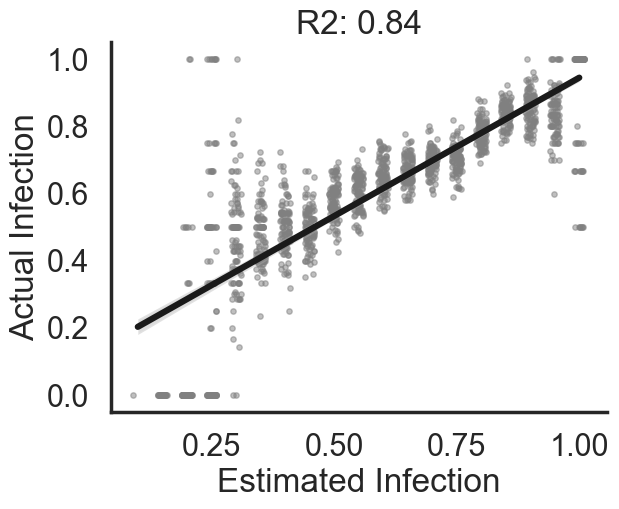

In [67]:
import matplotlib.pyplot as plt

sns.set_theme(context="poster", style="white", font_scale=1)

fig, ax = plt.subplots()

sns.regplot(
    data=bootstrap_counts,
    x="Estimated Infection",
    y="Actual Infection",
    ax=ax,
    scatter_kws={"color": "gray", "alpha": 0.5, "s": 15},
    line_kws={"color": "k", "alpha": 1},
    fit_reg=True,
    ci=95,
    x_jitter=0.01
)

ax.set_title(
    f"R2: {corr:.2f}"
)

sns.despine()

In [68]:
fig.savefig("infection.pdf", dpi=300, bbox_inches="tight")

In [69]:
combined_results.to_csv(
    "design_matrix_test_infection_risk.tsv",
    sep="\t"
)